---
title: "hft-ipc-bench Benchmark Report"
format:
  pdf:
    toc: true
    number-sections: true
    df-print: kable
execute:
  echo: false
  warning: false
  message: false
  cache: false
  freeze: false
---



# Introduction

This report evaluates several in-host inter-process communication (IPC) mechanisms for a high-frequency trading style market data fan-out workload. The benchmark models a single producer distributing fixed-size 64-byte messages to one or more local consumers. The goal is to compare typical latency, throughput capacity, and fan-out scaling behavior as the number of consumers increases.

The tested implementations are:

- **SHM (lock-free)**: a custom shared-memory ring-buffer implementation using POSIX shared memory and atomic coordination.
- **UDS stream**: a Unix domain socket baseline using one `SOCK_STREAM` connection per consumer and fixed-size 64-byte message framing.
- **ZeroMQ PUB/SUB**: a brokerless publish/subscribe baseline over local IPC transport.
- **gRPC streaming**: a server-streaming RPC implementation using Protocol Buffers and gRPC C++.

The analysis reads `output/analysis_summary.csv`. Because the benchmark was run inside a VM, tail latency can be affected by virtualization noise, vCPU scheduling, and host-side interference. For this reason, **P50 latency is treated as the primary latency metric**, while P90 and P99 are reported as supporting indicators rather than absolute HFT-grade tail-latency evidence.

# Testing Methodology

## SHM Result Preprocessing

SHM results are aggregated from multiple benchmark rounds rather than a single run. To reduce VM-induced noise, any SHM row with abnormal latency is removed before aggregation; in this report, rows with `p50_ns > 1000` are treated as outliers and the entire row is dropped. The remaining rows with the same configuration are averaged into `shm_final.csv`, and that preprocessed SHM summary is then merged into `analysis_summary.csv` for the report.

## System Requirement

| Item | Specification |
|---|---|
| CPU | Intel(R) Core(TM) i5-12400, 2.5 GHz |
| Memory | 32.0 GB |
| OS | Ubuntu 22.04 LTS running in a VM, x86-64 |
| Compiler | g++ |
| Permission | sudo |

## Dependencies

| Dependency Package | Purpose / Description |
|---|---|
| `build-essential`, `g++`, `make`, `pkg-config` | C++ build toolchain |
| `libzmq3-dev` | ZeroMQ C++ library |
| `libgrpc++-dev` | gRPC C++ library |
| `libprotobuf-dev` | Protobuf runtime |
| `protobuf-compiler` | `protoc` code generator |
| `protobuf-compiler-grpc` | gRPC plugin for `protoc` |
| `python3`, `python3-pip` | Runtime for analysis scripts |

Install command:

```bash
sudo apt-get install -y \
    libzmq3-dev \
    libgrpc++-dev libprotobuf-dev \
    protobuf-compiler protobuf-compiler-grpc \
    build-essential g++ pkg-config
```

Verification commands:

```bash
pkg-config --modversion libzmq
pkg-config --modversion grpc++
pkg-config --modversion protobuf

protoc --version
which grpc_cpp_plugin
```

## Build Process

Each module has an independent Makefile with no cross-dependencies, allowing the implementations to be built separately:

```bash
make -C shm
make -C uds
make -C zeroMQ
make -C grpc
```

## Test Execution

All benchmark runs are orchestrated by `run_bench.sh`, which starts the required producer, consumer, and gRPC server processes automatically.

```bash
./run_bench.sh
./run_bench.sh --ipc uds --msgs 1000000 --cons 4
```

Post-test analysis can be run with:

```bash
python3 analyze.py --out-dir ./output --plots-dir ./output/plots \
    --ipc-list shm uds zmq grpc \
    --msg-list 100000 1000000 10000000 \
    --cons-list 1 2 4 \
    --mps-list 2000000 5000000 10000000
```

## Test Case Matrix

| Parameter | Values |
|---|---|
| IPC Mechanism | `shm` / `uds` / `zmq` / `grpc` |
| Total Messages (N) | `100,000` / `1,000,000` / `10,000,000` |
| Consumer Count (C) | `1` / `2` / `4` |
| Target Send Rate | `2M` / `5M` / `10M` msg/s |

## Metrics

The main metric is **P50 end-to-end latency**, expressed in microseconds in this notebook. P90 and P99 are included for context. Actual throughput is computed from the number of messages received by the consumer and the elapsed wall-clock time between producer start and consumer completion. For multi-consumer runs, consumer-level measurements are averaged within the same workload configuration before cross-workload aggregation.


In [18]:
import os
from pathlib import Path

Path("/tmp/matplotlib").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

CSV_PATH = Path("output/analysis_summary.csv")
FIG_DIR = Path("output/csv_analysis_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

IPC_ORDER = ["shm", "uds", "zmq", "grpc"]
IPC_LABEL = {
    "shm": "SHM",
    "uds": "UDS stream",
    "zmq": "ZeroMQ",
    "grpc": "gRPC",
}
LAT_COLS = ["p50_ns", "p90_ns", "p99_ns"]

df = pd.read_csv(CSV_PATH)
df = df[df["ipc"].isin(IPC_ORDER)].copy()
df["ipc"] = pd.Categorical(df["ipc"], categories=IPC_ORDER, ordered=True)

numeric_cols = [
    "n_msgs", "n_cons", "target_mps", "consumer_id", "n_samples",
    "p50_ns", "p90_ns", "p99_ns", "p999_ns", "max_ns",
    "avg_jitter_ns", "max_jitter_ns", "elapsed_s", "throughput_mps",
    "n_recv", "n_exp", "loss",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["p50_ns", "p90_ns", "p99_ns", "p999_ns", "max_ns", "avg_jitter_ns", "max_jitter_ns"]:
    df[col.replace("_ns", "_us")] = df[col] / 1_000
    df[col.replace("_ns", "_ms")] = df[col] / 1_000_000

df["throughput_mps_million"] = df["throughput_mps"] / 1_000_000
df["target_mps_million"] = df["target_mps"] / 1_000_000
df["ipc_label"] = df["ipc"].map(IPC_LABEL)


# Latency Percentile Summary by Consumer Count and Target MPS

This table reports average P50, P90, and P99 latency for each IPC mechanism, consumer count, and target MPS. Rows are grouped by `ipc + n_cons + target_mps`, so with 4 IPC mechanisms, 3 consumer-count settings, and 3 target-MPS settings, the table should contain **36 rows**.

For SHM, the reported values come from `output/shm_final.csv`, which averages multiple rounds after dropping VM-noisy outlier rows with `p50_ns > 1000`.

P50 is the primary comparison metric in this VM-based benchmark. P90 and P99 are included to show tail-latency tendency, but they should be interpreted cautiously because VM scheduling can amplify tail behavior.


In [19]:
latency_points = df.dropna(subset=["p50_us", "p90_us", "target_mps", "n_cons"]).copy()

latency_by_cons_mps = (
    latency_points.groupby(
        ["ipc", "ipc_label", "n_cons", "target_mps", "target_mps_million"],
        observed=True,
    )
    .agg(
        p50_us=("p50_us", "mean"),
        p90_us=("p90_us", "mean"),
    )
    .reset_index()
    .sort_values(["ipc", "n_cons", "target_mps"])
)

expected_rows = len(IPC_ORDER) * latency_points["n_cons"].nunique() * latency_points["target_mps"].nunique()
print(f"Rows: {len(latency_by_cons_mps)} / expected {expected_rows}")

latency_by_cons_mps[
    ["ipc_label", "n_cons", "target_mps", "p50_us", "p90_us"]
].style.format({
    "n_cons": "{:.0f}",
    "target_mps": "{:,.0f}",
    "p50_us": "{:.2f}",
    "p90_us": "{:.2f}",
})


Rows: 36 / expected 36


,ipc_label,n_cons,target_mps,p50_us,p90_us
0,SHM,1,"2,000,000",0.16,1092.32
1,SHM,1,"5,000,000",0.16,738.56
2,SHM,1,"10,000,000",0.22,168.87
3,SHM,2,"2,000,000",0.18,787.17
4,SHM,2,"5,000,000",0.18,109.98
5,SHM,2,"10,000,000",0.24,92.09
6,SHM,4,"2,000,000",0.19,1025.35
7,SHM,4,"5,000,000",0.19,722.84
8,SHM,4,"10,000,000",0.24,315.51
9,UDS stream,1,"2,000,000",350.44,653.12


# P50 Latency Scaling by Consumer Count

This figure focuses on the main benchmark question: how typical latency changes as the number of consumers increases. For each `ipc + n_msgs + target_mps + n_cons` configuration, P50 values from multiple consumers are averaged first. Then, for each `ipc + n_cons`, the median across different message counts and target MPS values is used. This avoids overweighting C=2 or C=4 runs simply because they contain more consumer rows.

A lower bar indicates better typical latency. Since the y-axis is logarithmic, differences between mechanisms can span multiple orders of magnitude.


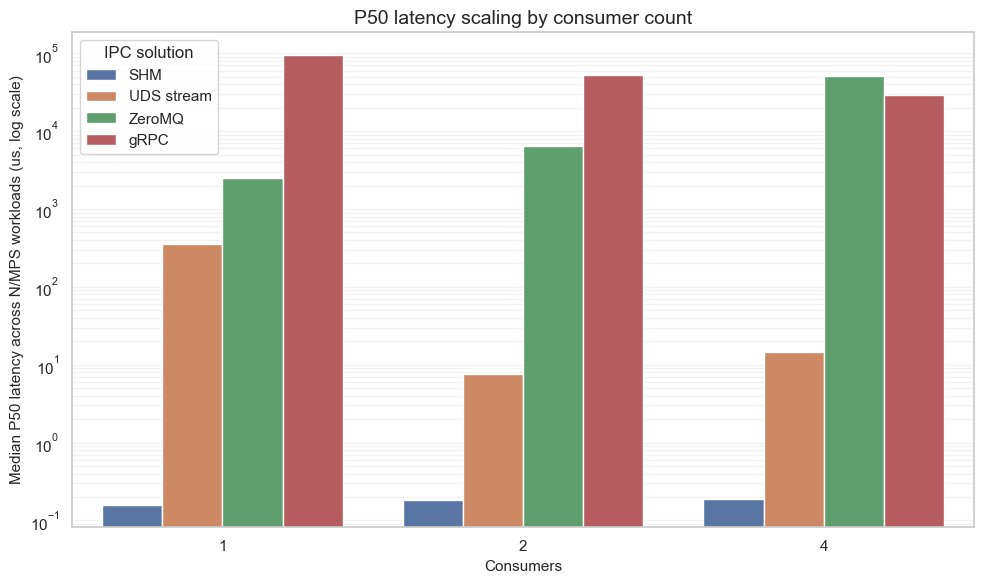

ipc_label,SHM,UDS stream,ZeroMQ,gRPC
n_cons,,,,
1,0.158882,352.800445,2483.337607,95464.077769
2,0.181602,7.516520,6468.448255,52016.682226
4,0.188493,14.473689,51124.220321,29051.460896


In [20]:
p50_points = df.dropna(subset=["p50_us", "n_msgs", "target_mps", "n_cons"]).copy()
p50_points["n_msgs_label"] = "N=" + p50_points["n_msgs"].astype(int).map("{:,}".format)
p50_points["target_mps_label"] = "MPS=" + p50_points["target_mps"].astype(int).map("{:,}".format)

p50_avg = (
    p50_points.groupby(
        ["ipc", "ipc_label", "n_msgs", "n_msgs_label", "target_mps", "target_mps_million", "target_mps_label", "n_cons"],
        observed=True,
    )
    .agg(
        p50_us_mean=("p50_us", "mean"),
    )
    .reset_index()
)

p50_by_cons = (
    p50_avg.groupby(["ipc", "ipc_label", "n_cons"], observed=True)
    .agg(
        p50_us_median=("p50_us_mean", "median"),
        workload_cases=("p50_us_mean", "size"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=p50_by_cons,
    x="n_cons",
    y="p50_us_median",
    hue="ipc_label",
    order=sorted(p50_avg["n_cons"].dropna().unique()),
    hue_order=[IPC_LABEL[x] for x in IPC_ORDER],
    errorbar=None,
    ax=ax,
)
ax.set_yscale("log")
ax.set_xlabel("Consumers")
ax.set_ylabel("Median P50 latency across N/MPS workloads (us, log scale)")
ax.set_title("P50 latency scaling by consumer count")
ax.grid(True, axis="y", which="both", alpha=0.25)
ax.legend(title="IPC solution")
fig.tight_layout()
fig.savefig(FIG_DIR / "p50_bar_by_consumers.png", dpi=160, bbox_inches="tight")
plt.show()

p50_by_cons.pivot(index="n_cons", columns="ipc_label", values="p50_us_median")

## Interpretation of the UDS and gRPC Consumer-Count Dip

UDS stream can show lower P50 latency at C=2 than at C=1 or C=4. This does not mean that adding consumers makes the IPC mechanism intrinsically faster. With C=1, the producer only writes to one FD, so at high target rates it can push data into the socket buffer faster than the consumer drains it; the measured latency then includes more queueing time. With C=4, each logical message requires four sequential fan-out sends, which increases producer-side work, scheduling pressure, and socket overhead. C=2 sits between these effects: the extra fan-out and kernel backpressure can keep the socket queue shallower, while the fan-out cost is still lower than C=4.

gRPC can show a similar pattern for the same queueing/backpressure reason, with extra effects from the RPC stack. A single stream may allow the server to enqueue work quickly and build up queueing delay, while multiple streams introduce flow control, completion-queue scheduling, serialization/deserialization work, and per-consumer fan-out cost. At moderate consumer count this can reduce queue buildup and lower P50, but as consumer count keeps increasing the additional RPC and scheduling overhead becomes dominant again.


# P50 Latency vs Target MPS at Fixed Consumer Counts

This plot keeps consumer count fixed in each column and message count fixed in each row, then shows how P50 latency changes as the target send rate increases. Multiple consumers in the same configuration are averaged before plotting, so a C=4 configuration contributes one point per IPC mechanism and target MPS.

This view helps separate fan-out scaling from send-rate pressure. If a mechanism is close to saturation, P50 latency may increase as the target MPS rises. If the producer cannot reach the requested rate, the actual-throughput section should be used together with this plot.


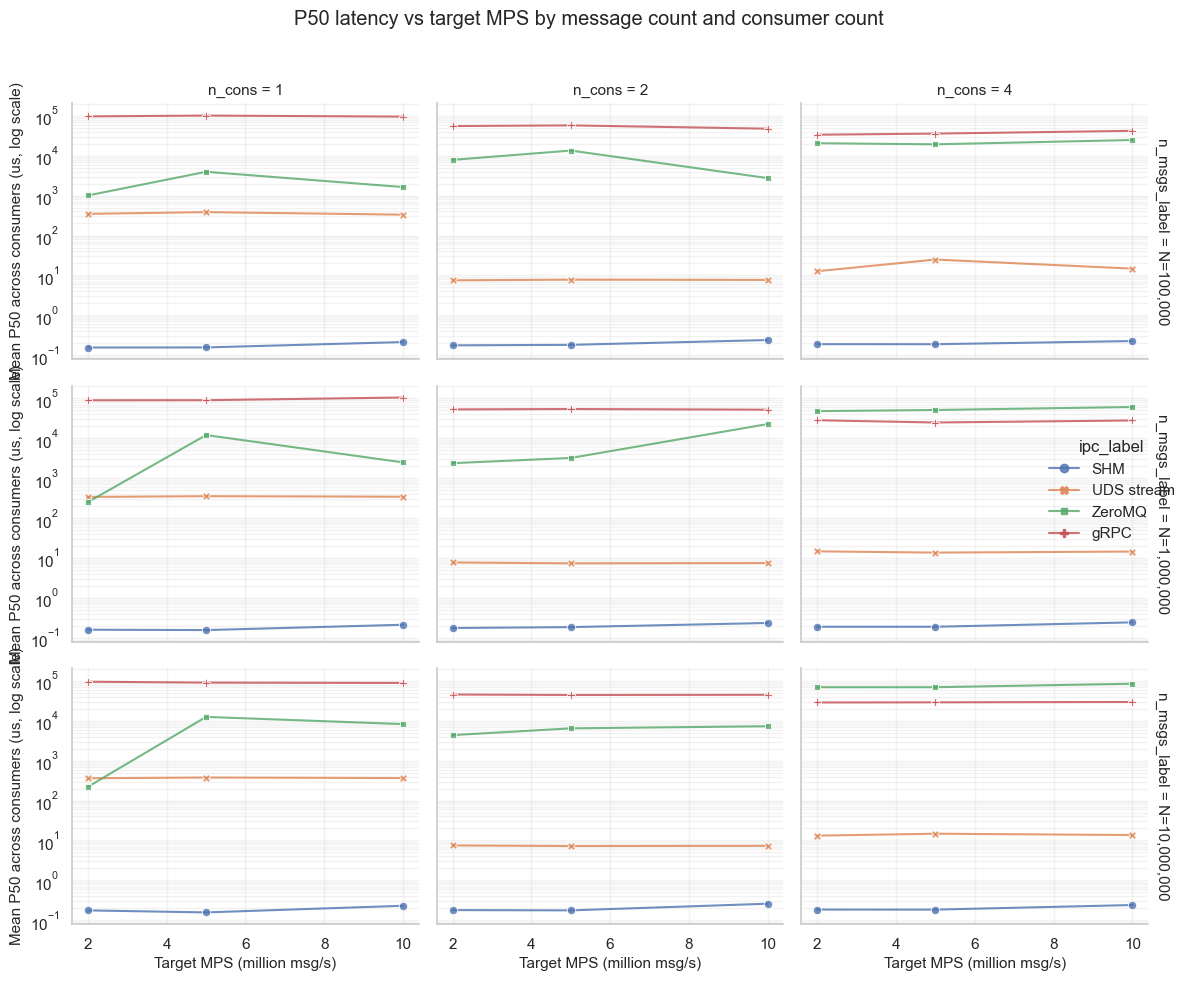

In [21]:
g = sns.relplot(
    data=p50_avg,
    x="target_mps_million",
    y="p50_us_mean",
    hue="ipc_label",
    style="ipc_label",
    row="n_msgs_label",
    col="n_cons",
    kind="line",
    markers=True,
    dashes=False,
    alpha=0.8,
    height=3.2,
    aspect=1.1,
    facet_kws={"sharey": True, "margin_titles": True},
)
g.set_axis_labels("Target MPS (million msg/s)", "Mean P50 across consumers (us, log scale)")
for ax in g.axes.flat:
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)
g.fig.suptitle("P50 latency vs target MPS by message count and consumer count", y=1.02)
g.fig.tight_layout()
g.fig.savefig(FIG_DIR / "p50_vs_target_mps_by_n_and_consumers.png", dpi=160, bbox_inches="tight")
plt.show()

# Throughput by Target MPS and Consumer Count

This section reports actual measured throughput. For each `ipc + n_msgs + target_mps + n_cons` configuration, throughput values from multiple consumers are averaged. The table includes the mean throughput in messages per second and the percentage of the target rate achieved.

The bar charts show actual throughput and target-achievement percentage across message counts, target MPS values, and consumer counts. UDS stream and gRPC may appear below SHM on a linear throughput scale because they pay kernel socket, copy, framing, or RPC-stack overhead that SHM avoids.


In [22]:
tp_points = df.dropna(subset=["throughput_mps", "n_msgs", "target_mps", "n_cons"]).copy()
tp_points["n_msgs_label"] = "N=" + tp_points["n_msgs"].astype(int).map("{:,}".format)
tp_points["target_mps_label"] = "Target MPS=" + tp_points["target_mps"].astype(int).map("{:,}".format)
tp_points["throughput_million_mps"] = tp_points["throughput_mps"] / 1_000_000

tp_avg = (
    tp_points.groupby(
        ["ipc", "ipc_label", "n_msgs", "n_msgs_label", "target_mps", "target_mps_million", "target_mps_label", "n_cons"],
        observed=True,
    )
    .agg(
        throughput_mps_mean=("throughput_mps", "mean"),
        throughput_mps_min=("throughput_mps", "min"),
        throughput_mps_max=("throughput_mps", "max"),
    )
    .reset_index()
)
tp_avg["throughput_million_mps_mean"] = tp_avg["throughput_mps_mean"] / 1_000_000
tp_avg["throughput_million_mps_min"] = tp_avg["throughput_mps_min"] / 1_000_000
tp_avg["throughput_million_mps_max"] = tp_avg["throughput_mps_max"] / 1_000_000
tp_avg["target_achievement_pct"] = tp_avg["throughput_mps_mean"] / tp_avg["target_mps"] * 100

tp_table = tp_avg[
    [
        "ipc_label", "n_msgs", "target_mps", "n_cons",
        "throughput_mps_mean", "target_achievement_pct",
    ]
].sort_values(["ipc_label", "n_msgs", "target_mps", "n_cons"])

tp_table.style.format({
    "n_msgs": "{:,}",
    "target_mps": "{:,}",
    "throughput_mps_mean": "{:,.0f}",
    "target_achievement_pct": "{:.2f}%",
})

,ipc_label,n_msgs,target_mps,n_cons,throughput_mps_mean,target_achievement_pct
0,SHM,"100,000","2,000,000",1,"1,995,896",99.79%
1,SHM,"100,000","2,000,000",2,"1,994,705",99.74%
2,SHM,"100,000","2,000,000",4,"1,932,076",96.60%
3,SHM,"100,000","5,000,000",1,"4,923,023",98.46%
4,SHM,"100,000","5,000,000",2,"4,965,179",99.30%
5,SHM,"100,000","5,000,000",4,"4,962,386",99.25%
6,SHM,"100,000","10,000,000",1,"9,824,811",98.25%
7,SHM,"100,000","10,000,000",2,"9,902,945",99.03%
8,SHM,"100,000","10,000,000",4,"9,793,731",97.94%
9,SHM,"1,000,000","2,000,000",1,"2,001,039",100.05%


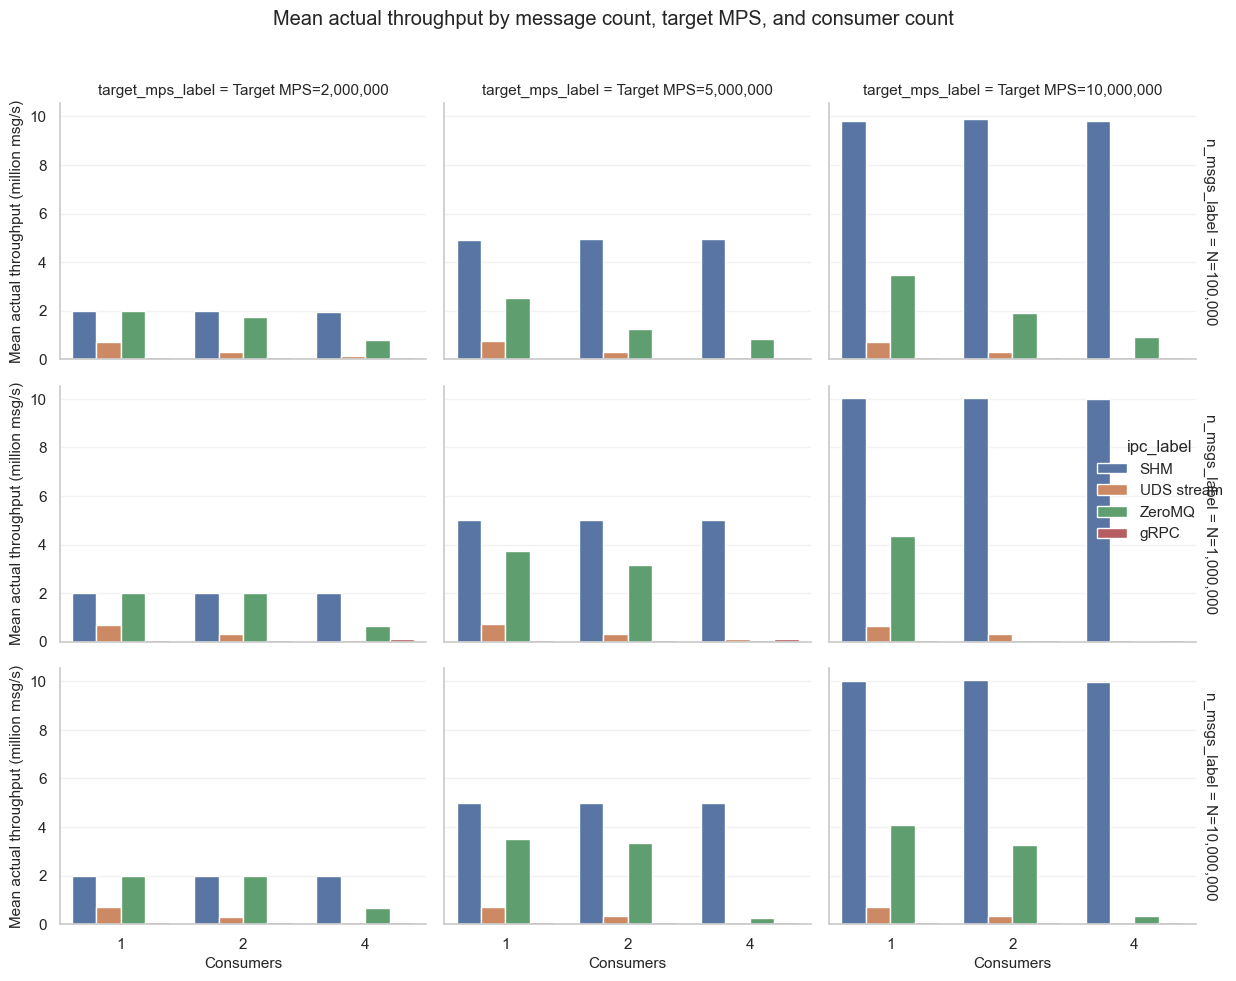

In [23]:
g = sns.catplot(
    data=tp_avg,
    x="n_cons",
    y="throughput_million_mps_mean",
    hue="ipc_label",
    row="n_msgs_label",
    col="target_mps_label",
    kind="bar",
    order=sorted(tp_avg["n_cons"].dropna().unique()),
    hue_order=[IPC_LABEL[x] for x in IPC_ORDER],
    errorbar=None,
    height=3.2,
    aspect=1.15,
    margin_titles=True,
)
g.set_axis_labels("Consumers", "Mean actual throughput (million msg/s)")
for ax in g.axes.flat:
    ax.grid(True, axis="y", alpha=0.25)
g.fig.suptitle("Mean actual throughput by message count, target MPS, and consumer count", y=1.02)
g.fig.tight_layout()
g.fig.savefig(FIG_DIR / "throughput_bar_by_n_mps_consumers.png", dpi=160, bbox_inches="tight")
plt.show()

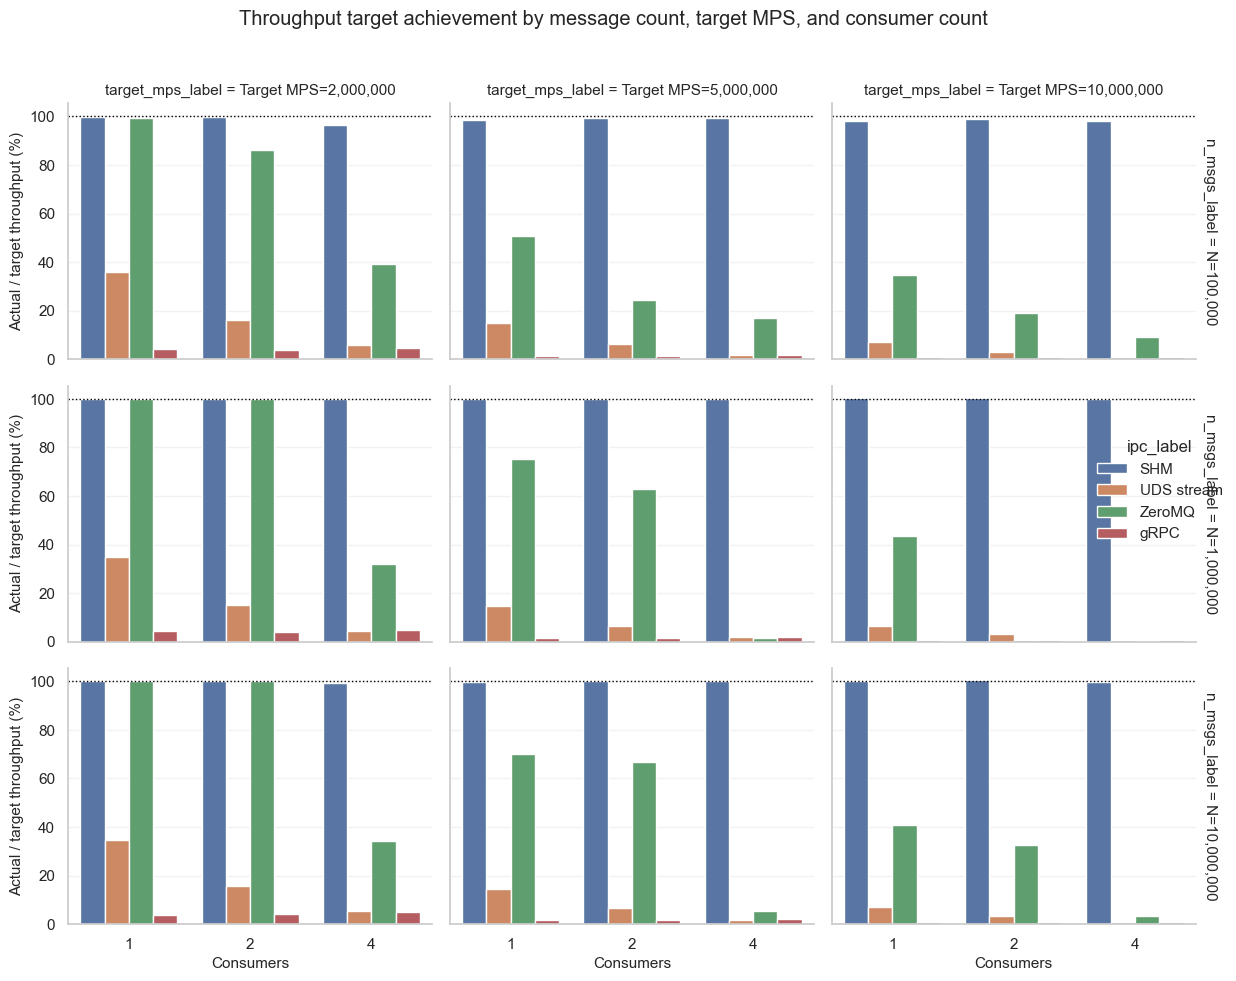

In [24]:
g = sns.catplot(
    data=tp_avg,
    x="n_cons",
    y="target_achievement_pct",
    hue="ipc_label",
    row="n_msgs_label",
    col="target_mps_label",
    kind="bar",
    order=sorted(tp_avg["n_cons"].dropna().unique()),
    hue_order=[IPC_LABEL[x] for x in IPC_ORDER],
    errorbar=None,
    height=3.2,
    aspect=1.15,
    margin_titles=True,
)
g.set_axis_labels("Consumers", "Actual / target throughput (%)")
for ax in g.axes.flat:
    ax.axhline(100, color="black", linestyle=":", linewidth=1)
    ax.grid(True, axis="y", alpha=0.25)
g.fig.suptitle("Throughput target achievement by message count, target MPS, and consumer count", y=1.02)
g.fig.tight_layout()
g.fig.savefig(FIG_DIR / "throughput_target_achievement_by_n_mps_consumers.png", dpi=160, bbox_inches="tight")
plt.show()

# Throughput vs P50 Latency

This scatter plot relates capacity and typical latency. The x-axis is actual measured throughput, and the y-axis is P50 latency. The ideal region is toward the lower-right corner: high throughput with low typical latency.

Because the x-axis uses actual throughput rather than target MPS, mechanisms that cannot reach the requested send rate will appear further left. This is important for interpreting UDS stream, ZeroMQ, and gRPC results: a low latency number is less meaningful if the achieved throughput is far below the target workload.


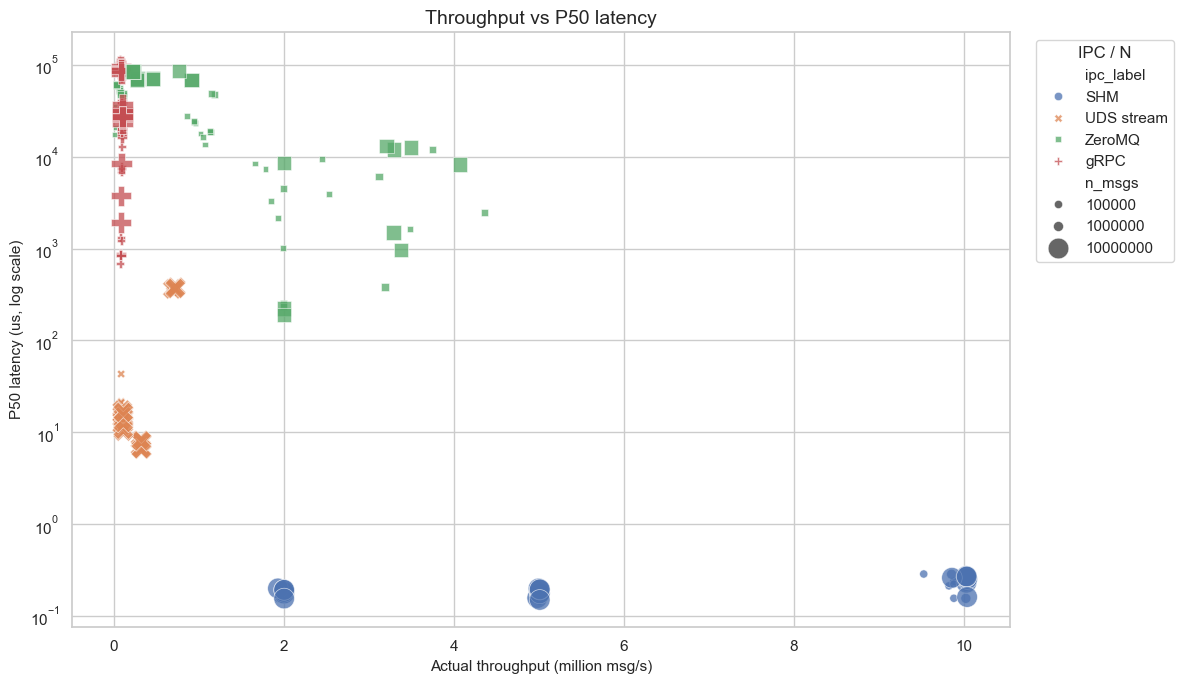

In [25]:
plot_df = df.dropna(subset=["throughput_mps_million", "p50_us", "n_msgs"]).copy()

fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=plot_df,
    x="throughput_mps_million",
    y="p50_us",
    hue="ipc_label",
    style="ipc_label",
    size="n_msgs",
    sizes=(35, 220),
    alpha=0.75,
    ax=ax,
)
ax.set_yscale("log")
ax.set_xlabel("Actual throughput (million msg/s)")
ax.set_ylabel("P50 latency (us, log scale)")
ax.set_title("Throughput vs P50 latency")
ax.legend(title="IPC / N", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "throughput_vs_p50.png", dpi=160, bbox_inches="tight")
plt.show()

# Loss by Target MPS

This table reports message-delivery loss aggregated by IPC mechanism and target send rate across all tested message counts and consumer counts. Loss is included as a reference metric rather than the primary ranking metric. This benchmark models local market-data fan-out, closer to latest-value dissemination than durable message persistence. In such pipelines, occasional dropped updates may be acceptable if sequence gaps are detectable and consumers can resynchronize from a newer snapshot or stream position. This does not apply to order, execution, or risk-control paths, where reliable delivery is required.


In [26]:
loss_points = df.dropna(subset=["target_mps", "n_recv", "n_exp", "loss"]).copy()

loss_by_mps = (
    loss_points.groupby(["ipc", "ipc_label", "target_mps", "target_mps_million"], observed=True)
    .agg(
        expected_messages=("n_exp", "sum"),
        received_messages=("n_recv", "sum"),
        lost_messages=("loss", "sum"),
    )
    .reset_index()
    .sort_values(["ipc", "target_mps"])
)
loss_by_mps["loss_rate_pct"] = np.where(
    loss_by_mps["expected_messages"] > 0,
    loss_by_mps["lost_messages"] / loss_by_mps["expected_messages"] * 100,
    np.nan,
)

loss_by_mps[[
    "ipc_label",
    "target_mps",
    "expected_messages",
    "received_messages",
    "lost_messages",
    "loss_rate_pct",
]].style.format({
    "target_mps": "{:,.0f}",
    "expected_messages": "{:,.0f}",
    "received_messages": "{:,.0f}",
    "lost_messages": "{:,.0f}",
    "loss_rate_pct": "{:.4f}%",
})


,ipc_label,target_mps,expected_messages,received_messages,lost_messages,loss_rate_pct
0,SHM,"2,000,000","77,700,000","77,341,156","358,844",0.4618%
1,SHM,"5,000,000","77,700,000","77,619,387","80,613",0.1037%
2,SHM,"10,000,000","77,700,000","77,488,209","211,791",0.2726%
3,UDS stream,"2,000,000","77,700,000","77,700,000",0,0.0000%
4,UDS stream,"5,000,000","77,700,000","77,700,000",0,0.0000%
5,UDS stream,"10,000,000","77,700,000","77,700,000",0,0.0000%
6,ZeroMQ,"2,000,000","77,700,000","54,741,827","22,958,173",29.5472%
7,ZeroMQ,"5,000,000","77,700,000","41,430,081","36,269,919",46.6794%
8,ZeroMQ,"10,000,000","77,700,000","38,216,788","39,483,212",50.8149%
9,gRPC,"2,000,000","77,700,000","77,700,000",0,0.0000%


# Result Summary and Conclusion

## Executive Summary

**Fastest Overall: SHM**

The custom lock-free shared-memory implementation remains the primary low-latency reference point. It avoids kernel socket copies and per-consumer send syscalls on the producer hot path, so it is expected to dominate the in-host fan-out workload when the custom shared-memory lifecycle is acceptable.

**Direct Kernel-Socket Baseline: UDS stream**

UDS stream provides a useful baseline between custom SHM and higher-level messaging stacks. It keeps the same 64-byte `Message` layout and uses one local stream connection per consumer, but the producer still performs one `send_all()` per consumer and each consumer reconstructs fixed-size messages with `recv_exact()`.

**General Messaging Baseline: ZeroMQ**

ZeroMQ remains the strongest general messaging-library baseline when a ready-made PUB/SUB abstraction is preferred. Its behavior under high target rates should be interpreted together with achieved throughput and loss.

**Highest-Abstraction Baseline: gRPC**

gRPC is useful for typed service communication and server-streaming APIs, but its serialization, RPC scheduling, and stream-management costs make it the least directly comparable to the 64-byte local fan-out fast path.

## Key Findings

- **SHM is the clear winner for in-host HFT-style fan-out.** It is the only implementation in this set that avoids per-message kernel socket send/receive overhead.
- **UDS stream is the right low-level socket baseline.** It gives every consumer a dedicated connection and preserves fixed-size message framing with explicit `send_all()` / `recv_exact()` handling.
- **Consumer count is a first-class scaling dimension.** The benchmark is not only a single-consumer latency test; it measures how each mechanism behaves as fan-out increases from C=1 to C=2 and C=4.
- **ZeroMQ is the strongest standard messaging baseline, but not a replacement for SHM latency.** Its library-level PUB/SUB abstraction is convenient, while overloaded cases must be checked for loss and throughput shortfall.
- **gRPC is convenient but not latency-competitive here.** It is valuable for typed service communication, but its abstraction cost is too high for this 64-byte local market-data fan-out workload.
- **VM results should be interpreted conservatively.** P50 is the primary metric in this report. P90/P99 are useful for trend inspection, but VM scheduling and host interference can distort tail-latency measurements.

## Recommendations

- **Use SHM** when the objective is minimum latency and maximum local throughput, and when the application can tolerate custom shared-memory lifecycle and synchronization code.
- **Use UDS stream** when you want a simple kernel-supported local IPC baseline with explicit one-connection-per-consumer fan-out and reliable byte-stream delivery.
- **Use ZeroMQ** when a standard messaging library is preferred and throughput matters more than sub-microsecond latency, while carefully handling high-load loss behavior.
- **Use gRPC** for service APIs and typed streaming interfaces, not for ultra-low-latency market-data distribution.
- **Repeat on bare metal** for final HFT claims. A bare-metal Linux run with CPU pinning, isolated cores, and hardware performance counters would provide more reliable P99 and micro-architectural measurements.
